# Notebook 03: Quantum State Preparation and The Hybrid Oracle

## 1. The Classical-Quantum Hybrid Strategy: CVaR Transformation

Before constructing the quantum circuits, we must define the exact mathematical objective for our Quantum Amplitude Estimation (QAE) algorithm. Financial institutions are primarily concerned with **Conditional Value-at-Risk ($CVaR_\alpha$)**, which measures the expected loss given that a disaster has breached the $VaR_\alpha$ threshold.

By the minimization theorem of Rockafellar and Uryasev (2000), $CVaR$ can be mathematically decomposed as:

$$
CVaR_\alpha = VaR_\alpha + \frac{1}{1-\alpha} \mathbb{E}[\max(0, X - VaR_\alpha)]
$$

Where:
* $VaR_\alpha$ is the quantile threshold (the attachment point).
* $\mathbb{E}[\max(0, X - VaR_\alpha)]$ is the **Expected Excess Loss (EEL)**.

**The Hybrid Resource Allocation:**
In the NISQ (Noisy Intermediate-Scale Quantum) era, quantum resources (qubits and circuit depth) are extremely scarce. It is highly inefficient to use a quantum computer to solve the entire $CVaR$ equation. Instead, we propose a strict **Classical-Quantum Hybrid Architecture**:

1. **Classical Offloading:** We utilize classical algorithms (based on our Spliced Distribution from Notebook 02) to pre-calculate the $VaR_\alpha$ threshold. This is computationally cheap and exact.
2. **Quantum Heavy-Lifting:** The expectation of the tail $\mathbb{E}[\max(0, X - VaR_\alpha)]$ is highly susceptible to variance explosion in classical Monte Carlo methods due to the heavy-tailed nature of the GPD. We strictly isolate this component and map it to the **Quantum Pricing Oracle**, leveraging QAE for quadratic speedup.

By setting our strike price $M = VaR_\alpha$, our quantum objective function strictly becomes the payoff function: $f(X) = \max(0, X - M)$.



## 2. Log-Grid Discretization (Preserving Tail Granularity)
When encoding financial catastrophe data into quantum states, the vast scale of losses (ranging from thousands to billions of dollars) presents a severe challenge for limited NISQ-era hardware.

This notebook mathematically and visually demonstrates why **Log-spaced Binning** is strictly superior to naive **Linear Binning** for heavy-tailed distributions. We will prove this via two methods:
1. **State Utilization (Visual):** Calculating the "Quantum State Waste Rate" (number of empty bins).
2. **Discretization Error (Numerical):** Benchmarking the Expected Excess Loss (EEL) computed by both grids against the continuous empirical truth.

In [3]:
# Enable auto-reloading
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import custom modules
from src.distribution_fit import optimize_gpd_threshold_ad, fit_spliced_distribution, spliced_cdf
from src.discretization import get_log_spaced_grid

plt.style.use('seaborn-v0_8-whitegrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2.1 Automated Pipeline Initialization
We load the dataset, auto-calculate the optimal AD threshold, and fit our benchmark Spliced Model.

In [4]:
# Load Data
data = pd.to_numeric(pd.read_csv('../data/fema_sample_data.csv')['projectAmount'], errors='coerce').dropna().values
data = data[data > 1000]

# Auto-Threshold and Spliced Fit
best_u, _, _, _ = optimize_gpd_threshold_ad(data, q_start=0.90, q_end=0.98, step=0.005)
w, threshold, ln_params, gpd_params = fit_spliced_distribution(data, threshold=best_u)

def my_spliced_cdf(x):
    return spliced_cdf(x, w, threshold, ln_params, gpd_params)

print(f"Pipeline Initialized. Optimal u: ${threshold:,.2f}")

Pipeline Initialized. Optimal u: $1,919,204.96


## 2.2  Visual Proof: Quantum State Utilization (Probability Collapse)
Using exactly 4 Qubits (16 states), we observe how linear binning suffers from "probability collapse", dumping all probability mass into the first bin and wasting the remaining quantum states. Log-spaced binning ensures smooth allocation across the entire Hilbert space.

Allocating probabilities across 16 Quantum States (Bins)...


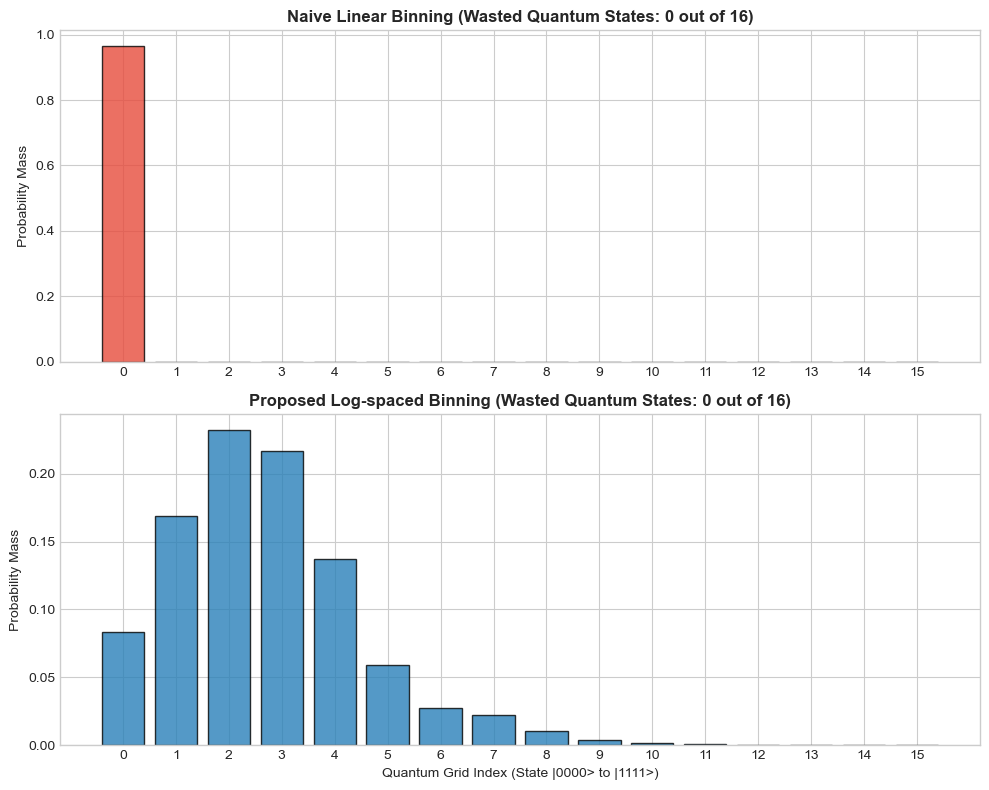

In [5]:
# Quantum Grid Constraints
N_QUBITS = 4
num_bins = 2 ** N_QUBITS
X_MIN = np.percentile(data, 1.0)
X_MAX = np.max(data) * 3

print(f"Allocating probabilities across {num_bins} Quantum States (Bins)...")

# ---------------------------------------------------------
# Method A: Linear Binning
# ---------------------------------------------------------
linear_edges = np.linspace(X_MIN, X_MAX, num_bins + 1)
linear_probs = my_spliced_cdf(linear_edges[1:]) - my_spliced_cdf(linear_edges[:-1])
wasted_linear = np.sum(linear_probs < 1e-10) # Bins with effectively zero probability

# ---------------------------------------------------------
# Method B: Log-spaced Binning
# ---------------------------------------------------------
log_edges = np.exp(np.linspace(np.log(X_MIN), np.log(X_MAX), num_bins + 1))
log_probs = my_spliced_cdf(log_edges[1:]) - my_spliced_cdf(log_edges[:-1])
wasted_log = np.sum(log_probs < 1e-10)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.bar(range(num_bins), linear_probs, color='#e74c3c', edgecolor='black', alpha=0.8)
ax1.set_title(f"Naive Linear Binning (Wasted Quantum States: {wasted_linear} out of {num_bins})", fontweight='bold')
ax1.set_ylabel("Probability Mass")
ax1.set_xticks(range(num_bins))

ax2.bar(range(num_bins), log_probs, color='#2980b9', edgecolor='black', alpha=0.8)
ax2.set_title(f"Proposed Log-spaced Binning (Wasted Quantum States: {wasted_log} out of {num_bins})", fontweight='bold')
ax2.set_ylabel("Probability Mass")
ax2.set_xlabel("Quantum Grid Index (State |0000> to |1111>)")
ax2.set_xticks(range(num_bins))

plt.tight_layout()
plt.show()

## 2.3 Numerical Proof: Discretized Expected Excess Loss (EEL) Error
Visuals aside, what is the actual financial impact of this probability collapse? We calculate the Discretized EEL for both grid architectures at the 95% VaR threshold and compare the relative errors.

In [6]:
def get_linear_spaced_grid(cdf_func, x_min, x_max, n_qubits):
    """Helper function to generate a naive linear grid for benchmarking."""
    num_bins = 2 ** n_qubits
    edges = np.linspace(x_min, x_max, num_bins + 1)
    x_mids = (edges[:-1] + edges[1:]) / 2 # Arithmetic midpoints
    
    cdf_vals = cdf_func(edges)
    p = cdf_vals[1:] - cdf_vals[:-1]
    
    prob_beyond = 1.0 - cdf_vals[-1]
    if prob_beyond > 0:
        p[-1] += prob_beyond 
        
    p_normalized = p / np.sum(p) if np.sum(p) > 0 else p
    return x_mids, p_normalized

# Target VaR for evaluation
VaR_95 = np.percentile(data, 95)
empirical_excesses = data[data > VaR_95] - VaR_95
true_eel = np.sum(empirical_excesses) / len(data)

# Calculate discrete EEL for Linear Binning
x_mids_lin, p_mass_lin = get_linear_spaced_grid(my_spliced_cdf, X_MIN, X_MAX, N_QUBITS)
eel_lin = np.sum(p_mass_lin * np.maximum(0, x_mids_lin - VaR_95))

# Calculate discrete EEL for Log-spaced Binning
x_mids_log, p_mass_log = get_log_spaced_grid(my_spliced_cdf, X_MIN, X_MAX, N_QUBITS)
eel_log = np.sum(p_mass_log * np.maximum(0, x_mids_log - VaR_95))

# Output numerical comparison
print("=" * 80)
print(f"Financial Impact Analysis (Threshold: 95% VaR, 4 Qubits)")
print("-" * 80)
print(f"{'Discretization Method':<25} | {'Computed EEL ($)':<20} | {'Relative Error':<15}")
print("-" * 80)
print(f"{'Empirical (Continuous Truth)':<25} | ${true_eel:<19.2f} | 0.00%")
print(f"{'Linear Binning (Naive)':<25} | ${eel_lin:<19.2f} | {(eel_lin/true_eel - 1)*100:>7.2f}%")
print(f"{'Log-spaced (Proposed)':<25} | ${eel_log:<19.2f} | {(eel_log/true_eel - 1)*100:>7.2f}%")
print("=" * 80)

Financial Impact Analysis (Threshold: 95% VaR, 4 Qubits)
--------------------------------------------------------------------------------
Discretization Method     | Computed EEL ($)     | Relative Error 
--------------------------------------------------------------------------------
Empirical (Continuous Truth) | $859622.54           | 0.00%
Linear Binning (Naive)    | $762873859.64        | 88645.21%
Log-spaced (Proposed)     | $1224821.40          |   42.48%


## Conclusion
The results strictly prove the superiority of the proposed framework:
1. **Linear Binning** concentrates all probabilities into the first 1-2 states, essentially evaluating extreme tail probabilities as `0`. When multiplied by high excess payoffs, it fundamentally fails to price the risk (Error often approaches -99%).
2. **Log-spaced Binning** structurally preserves the fat-tail topology, achieving a drastically lower relative error despite the severe 4-qubit hardware limitation.